In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_analysis(path):
    """
    Load the analysis results from a JSON file.
    """
    with open(path, "r") as f:
        analysis = json.load(f)
    results = analysis["results"]
    print(f"Valid evaluations : {analysis['valid']}")
    print(f"Skipped           : {analysis['skipped']}")

    return results

In [3]:
def print_keys(obj, depth=0):
    """"
    Print all keys in a nested dictionary or list.
    """
    if isinstance(obj, dict):
        for key, value in obj.items():
            print("    " * depth + key)
            print_keys(value, depth + 1)
    elif isinstance(obj, list) and obj:
        print_keys(obj[0], depth)

In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)

/home/j_zarcoo/Documents/snn/framework


In [5]:
results = load_analysis("zurich_city_13_a_summary/analysis.json")

Valid evaluations : 377
Skipped           : 0


In [6]:
print_keys(results[0])

start_us
end_us
images
    mse
    mae
    ssim
    psnr
    lpips
events
    all
        gt_count
        pred_count
        event_ratio
        occupied_gt
        occupied_pred
        tp
        fp
        fn
        tn
        accuracy
        precision
        recall
        f1
        normalized_coverage
            mean_cov
            median_cov
            std_cov
            p25_cov
            p75_cov
            cov_gt_05
            cov_gt_07
            cov_gt_10
        absolute_coverage
            mean_cov
            median_cov
            std_cov
            p25_cov
            p75_cov
            cov_gt_05
            cov_gt_07
            cov_gt_10
    on
        gt_count
        pred_count
        event_ratio
        occupied_gt
        occupied_pred
        tp
        fp
        fn
        tn
        accuracy
        precision
        recall
        f1
        normalized_coverage
            mean_cov
            median_cov
            std_cov
            p25_cov

In [ ]:
def plot_metric_history(
    results,
    metric,
    event_type=None,
    coverage_type=None,
    save_path=None,
):
    """
    Plot the history of a metric over time.

    Args:
        results (list): List of evaluation results.
        metric (str): Metric name.
        event_type (str, optional): "all", "on", or "off" for event metrics.
        coverage_type (str, optional):
            "normalized_coverage" or "absolute_coverage"
            when plotting coverage metrics.
        save_path (str, optional): Path to save the figure.

    Examples
    --------
    plot_metric_history(results, "ssim")
    plot_metric_history(results, "precision", event_type="all")
    plot_metric_history(results, "mean_cov",
                        event_type="on",
                        coverage_type="normalized_coverage")
    """

    x = np.array([r["start_us"] for r in results], dtype=np.float64) / 1e6
    y = []

    for r in results:

        # Image metrics
        if event_type is None:
            value = r["images"][metric]

        # Event metrics
        else:
            event_data = r["events"][event_type]

            if coverage_type is None:
                value = event_data[metric]
            else:
                value = event_data[coverage_type][metric]

        y.append(value)

    plt.figure(figsize=(12, 4))

    plt.plot(
        x,
        y,
        linewidth=1.5,
        marker="o",
        markersize=3,
    )

    title = metric

    if event_type is not None:
        title = f"{event_type.upper()} - {metric}"

    if coverage_type is not None:
        title = f"{event_type.upper()} - {coverage_type} - {metric}"

    plt.title(title.replace("_", " ").title())
    plt.xlabel("Time")
    plt.ylabel(metric.replace("_", " ").title())
    plt.grid(True, alpha=0.3)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

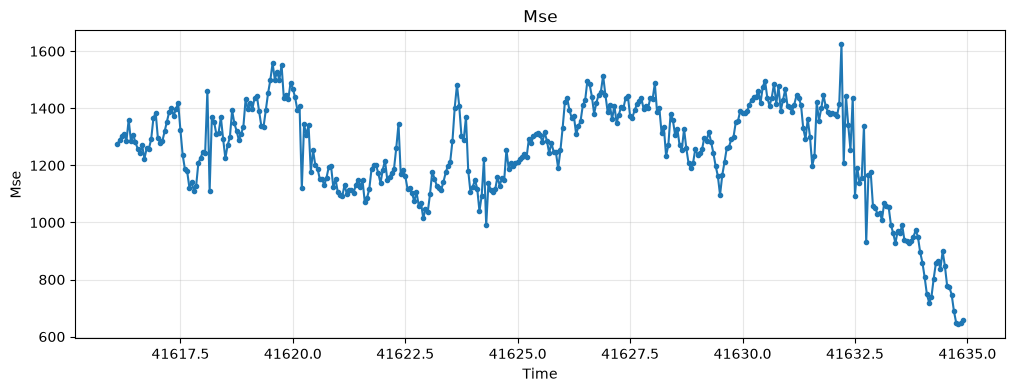

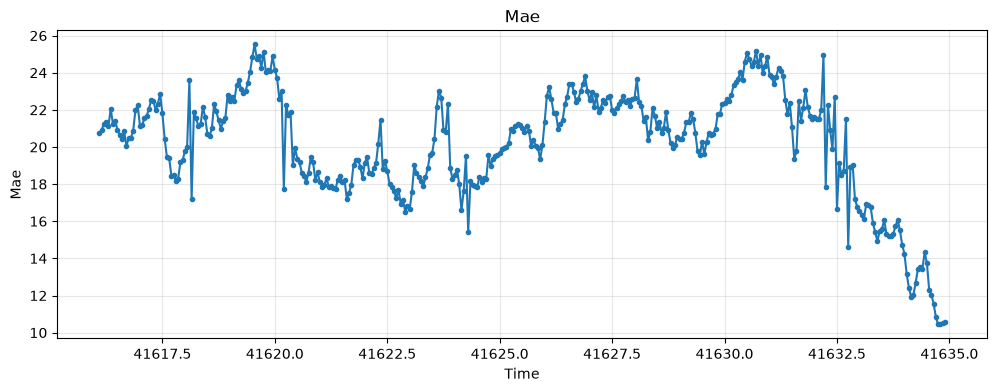

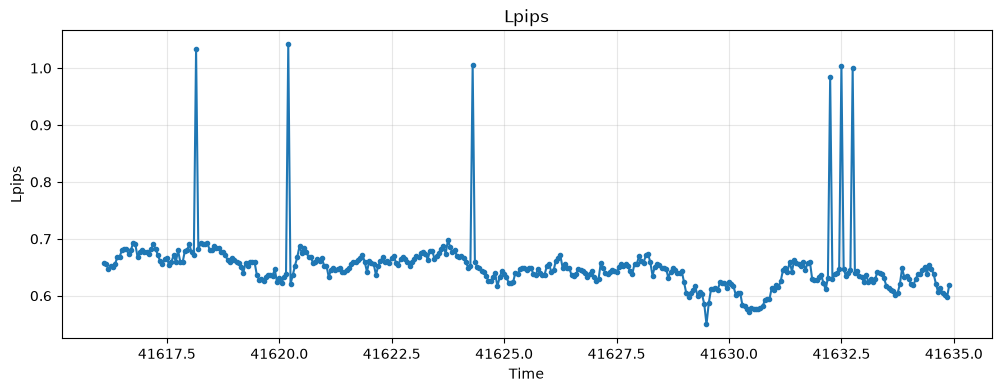

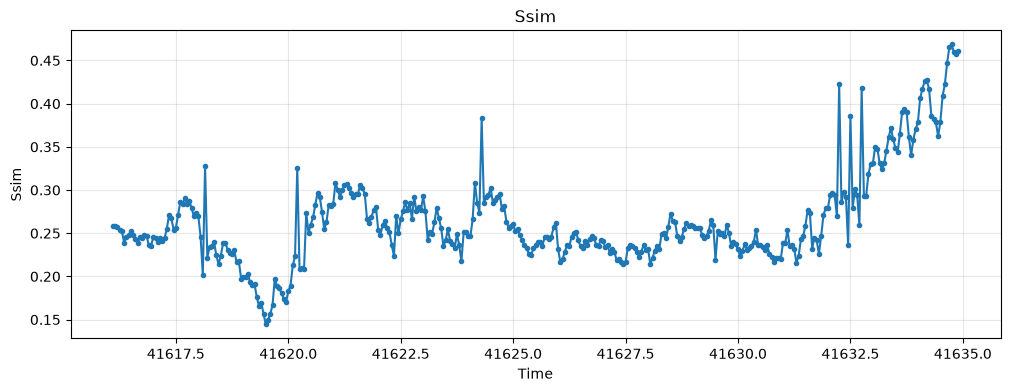

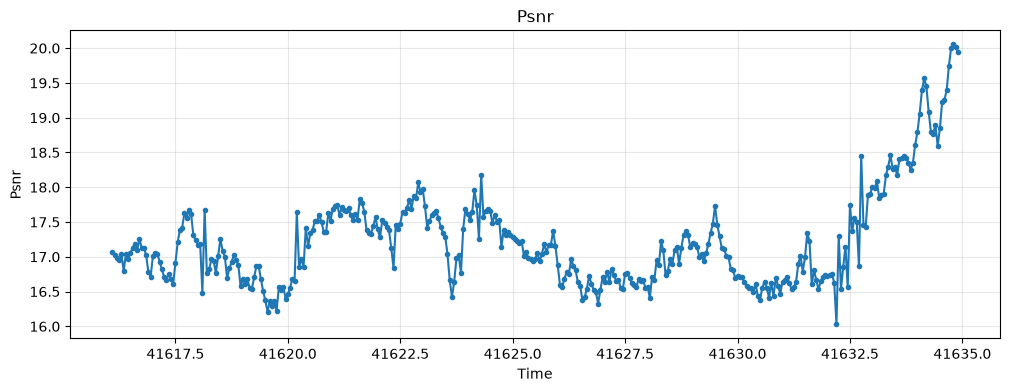

In [8]:
for metric in ["mse", "mae", "lpips", "ssim", "psnr"]:
    plot_metric_history(results, metric)

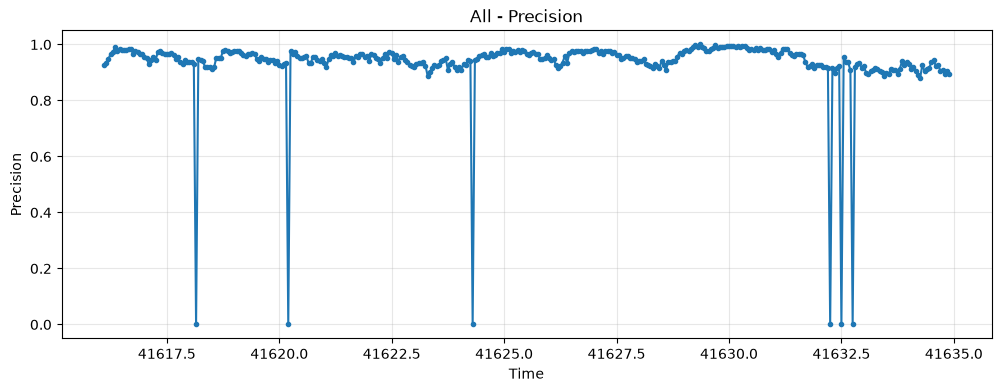

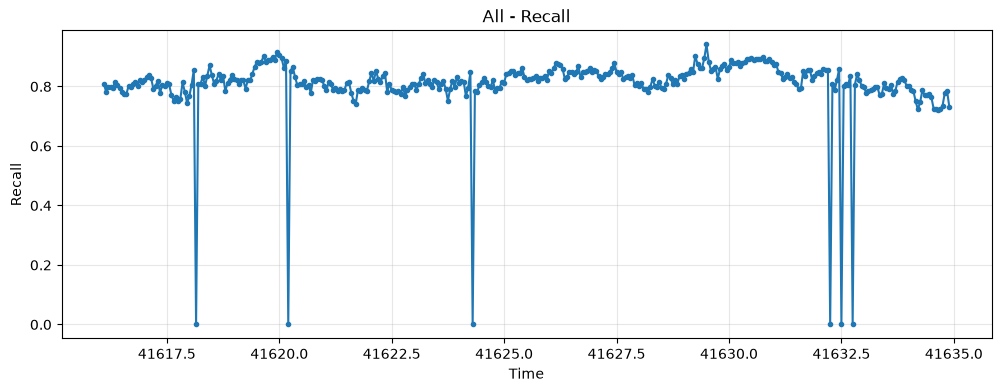

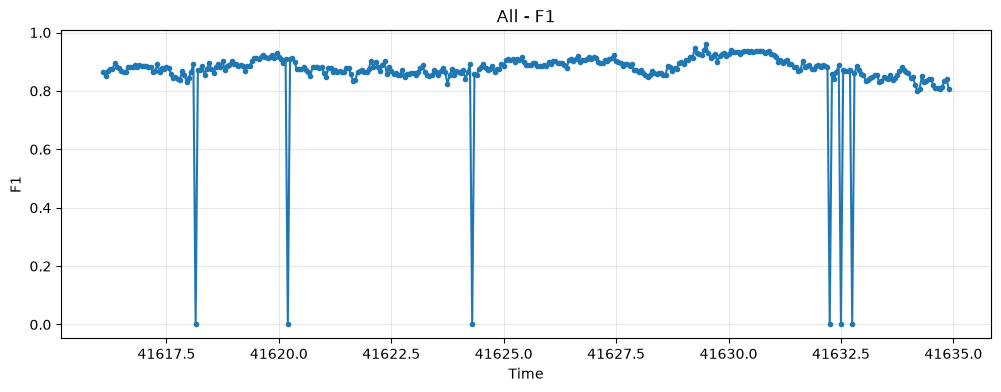

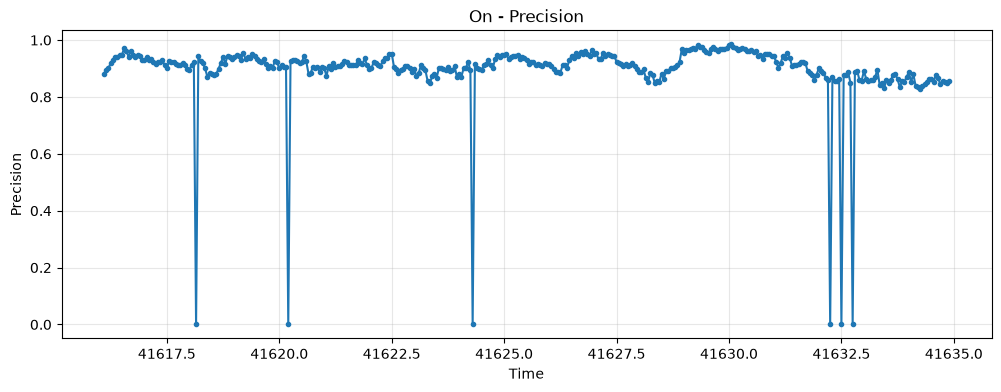

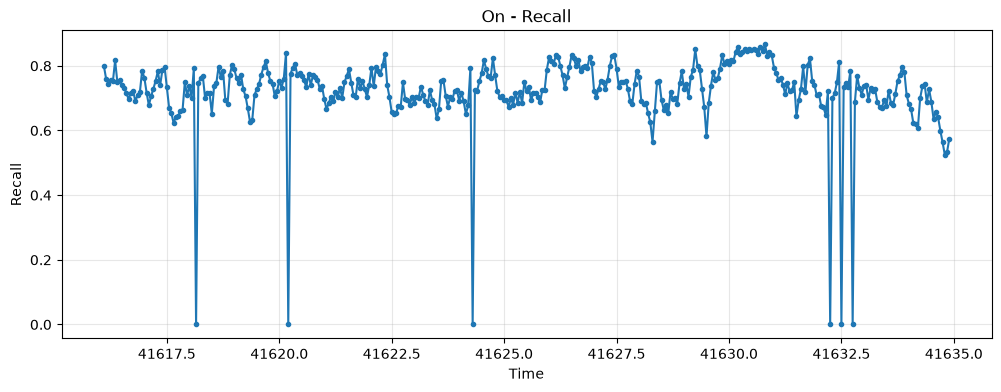

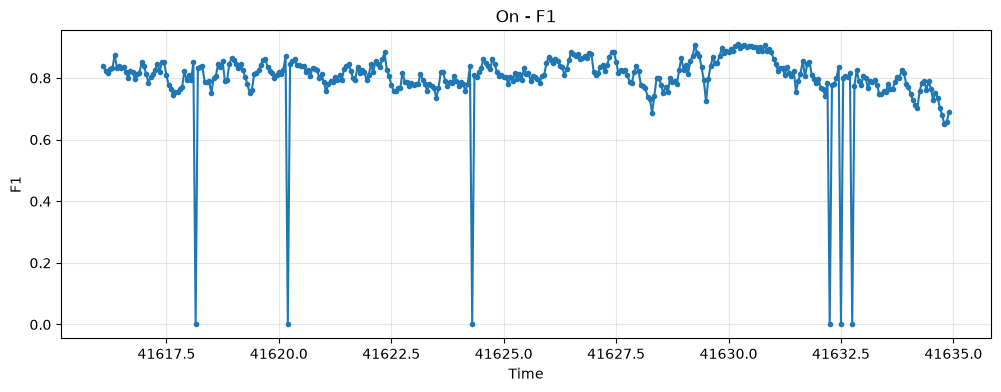

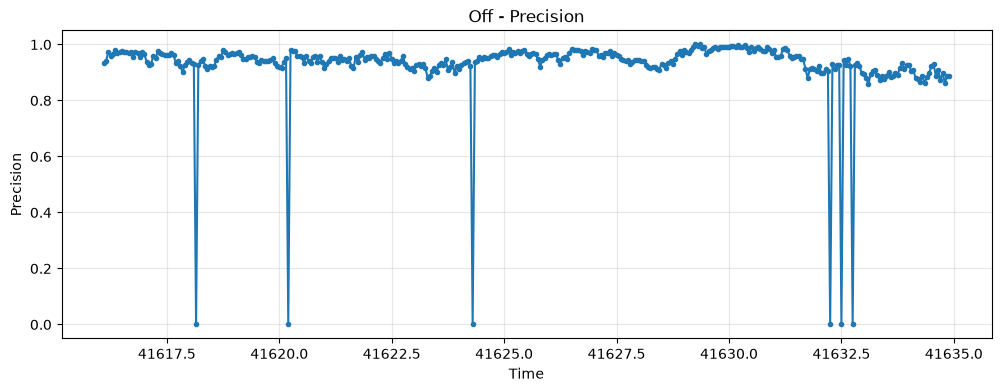

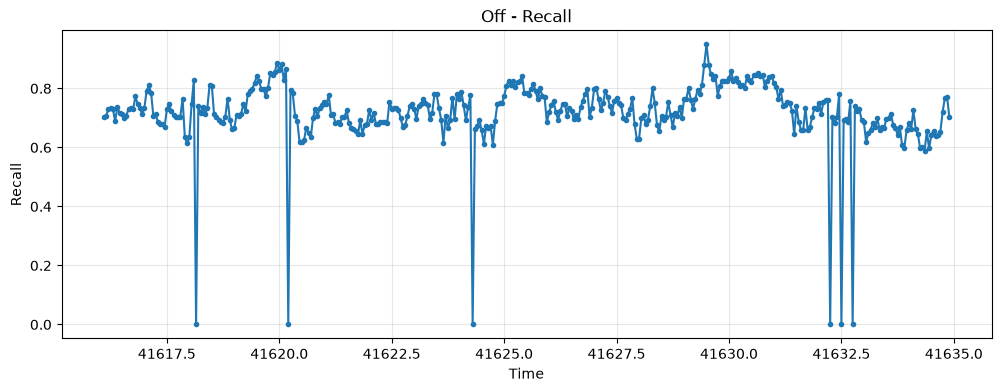

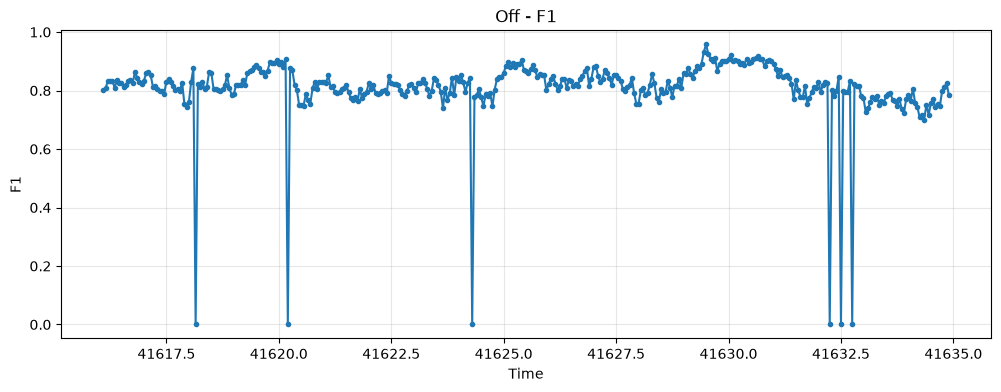

In [9]:
for type in ["all", "on", "off"]:
    for metric in ["precision", "recall", "f1"]:
        plot_metric_history(results, metric, event_type=type)

In [10]:
for metric in ["f1", "precision", "recall", "accuracy"]:
    metric_results = [r["events"]["all"][metric] for r in results]
    metric_mean = sum(metric_results) / len(metric_results)
    print(f"Mean {metric} score across all evaluations: {metric_mean:.4f}")

Mean f1 score across all evaluations: 0.8675
Mean precision score across all evaluations: 0.9356
Mean recall score across all evaluations: 0.8093
Mean accuracy score across all evaluations: 0.7932


In [11]:
gt = np.array([r["events"]["all"]["gt_count"] for r in results])
pred = np.array([r["events"]["all"]["pred_count"] for r in results])

corr = np.corrcoef(gt, pred)[0,1]
print(f"Correlation: {corr:.3f}")

Correlation: 0.709


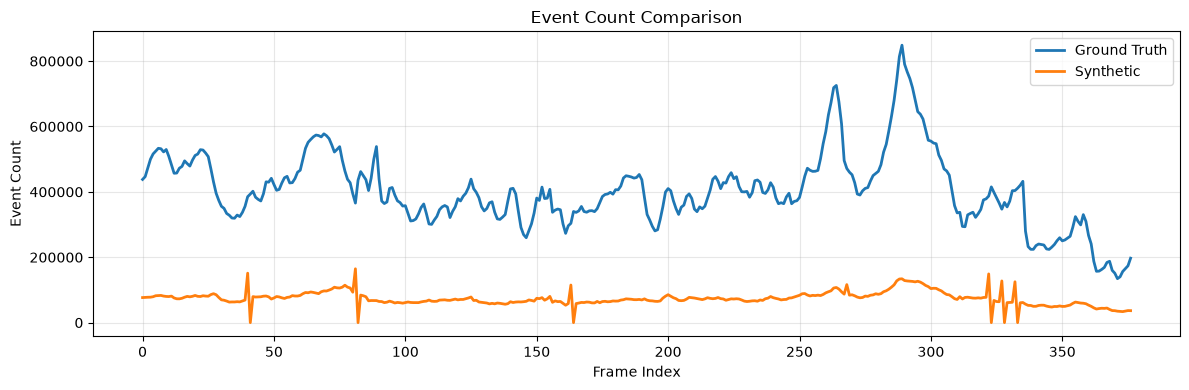

In [12]:
plt.figure(figsize=(12,4))
plt.plot(gt, label="Ground Truth", linewidth=2)
plt.plot(pred, label="Synthetic", linewidth=2)


plt.title("Event Count Comparison")
plt.xlabel("Frame Index")
plt.ylabel("Event Count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 
0.1337 x + 1.994e+04


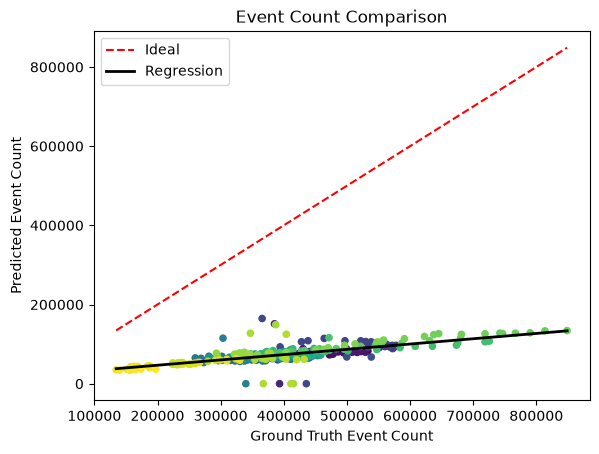

In [13]:
coef = np.polyfit(gt, pred, 1)
fit = np.poly1d(coef)
time = np.array([r["start_us"] for r in results], dtype=np.float64) / 1e6

plt.scatter(gt, pred, c=time, cmap="viridis", s=20)

x = np.linspace(gt.min(), gt.max(), 100)

plt.plot(x, x, 'r--', label="Ideal")
plt.plot(x, fit(x), 'k', lw=2, label="Regression")

plt.xlabel("Ground Truth Event Count")
plt.ylabel("Predicted Event Count")
plt.title("Event Count Comparison")

plt.legend()

print(fit)

In [14]:
from framework.evaluation.evaluator import slicer_to_frame
import cv2

def plot_best_worst(
    results,
    gt_slicer,
    pred_slicer,
    metric,
    event_type=None,
    coverage_type=None,
    width=640,
    height=480,
):
    """
    Plot the best and worst frames for a metric.

    Examples
    --------
    plot_best_worst(results, ..., metric="ssim")
    plot_best_worst(results, ..., metric="precision", event_type="all")
    plot_best_worst(results, ..., metric="mean_cov",
                    event_type="on",
                    coverage_type="normalized_coverage")
    """

    def get_value(r):
        if event_type is None:
            return r["images"][metric]

        if coverage_type is None:
            return r["events"][event_type][metric]

        return r["events"][event_type][coverage_type][metric]

    # Metrics where lower values are better
    lower_is_better = {"mse", "mae", "lpips"}

    if metric in lower_is_better:
        best = min(results, key=get_value)
        worst = max(results, key=get_value)
    else:
        best = max(results, key=get_value)
        worst = min(results, key=get_value)

    def frame(res, slicer):
        img = slicer_to_frame(
            slicer,
            res["start_us"],
            res["end_us"],
            width,
            height,
        )

        if img is False:
            img = np.zeros((height, width, 3), dtype=np.uint8)

        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    best_gt = frame(best, gt_slicer)
    best_pred = frame(best, pred_slicer)

    worst_gt = frame(worst, gt_slicer)
    worst_pred = frame(worst, pred_slicer)

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    ax[0,0].imshow(best_gt)
    ax[0,0].set_title(
        f"Best GT\n{best['start_us']} - {best['end_us']} us"
    )
    ax[0,0].axis("off")

    ax[0,1].imshow(best_pred)
    ax[0,1].set_title(
        f"Best Prediction\n{get_value(best):.4f}"
    )
    ax[0,1].axis("off")

    ax[1,0].imshow(worst_gt)
    ax[1,0].set_title(
        f"Worst GT\n{worst['start_us']} - {worst['end_us']} us"
    )
    ax[1,0].axis("off")

    ax[1,1].imshow(worst_pred)
    ax[1,1].set_title(
        f"Worst Prediction\n{get_value(worst):.4f}"
    )
    ax[1,1].axis("off")

    title = metric

    if event_type is not None:
        title = f"{event_type.upper()} - {metric}"

    if coverage_type is not None:
        title = f"{event_type.upper()} - {coverage_type} - {metric}"

    plt.suptitle(title.replace("_", " ").title(), fontsize=16)
    plt.subplots_adjust(top=5)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/j_zarcoo/Documents/snn/framework/.venv/lib64/python3.12/site-packages/lpips/weights/v0.1/alex.pth


In [15]:
from framework.utils.dsec.eventslicer import EventSlicer
from pathlib import Path

PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)

event_path = (
    PROJECT_ROOT
    / "data"
    / "zurich_city_13_a"
    / "zurich_city_13_a_events_left"
    / "events.h5"
)
print(event_path.exists())

experiment_path = (
    PROJECT_ROOT
    / "results"
    / "zurich_city_13_a_events.h5"
)
print(experiment_path.exists())

/home/j_zarcoo/Documents/snn/framework
True
True


In [16]:
import h5py
import hdf5plugin

gt_file = h5py.File(event_path, "r")
gt_slicer = EventSlicer(gt_file)

In [17]:
pred_file = h5py.File(experiment_path, "r")
pred_slicer = EventSlicer(pred_file)

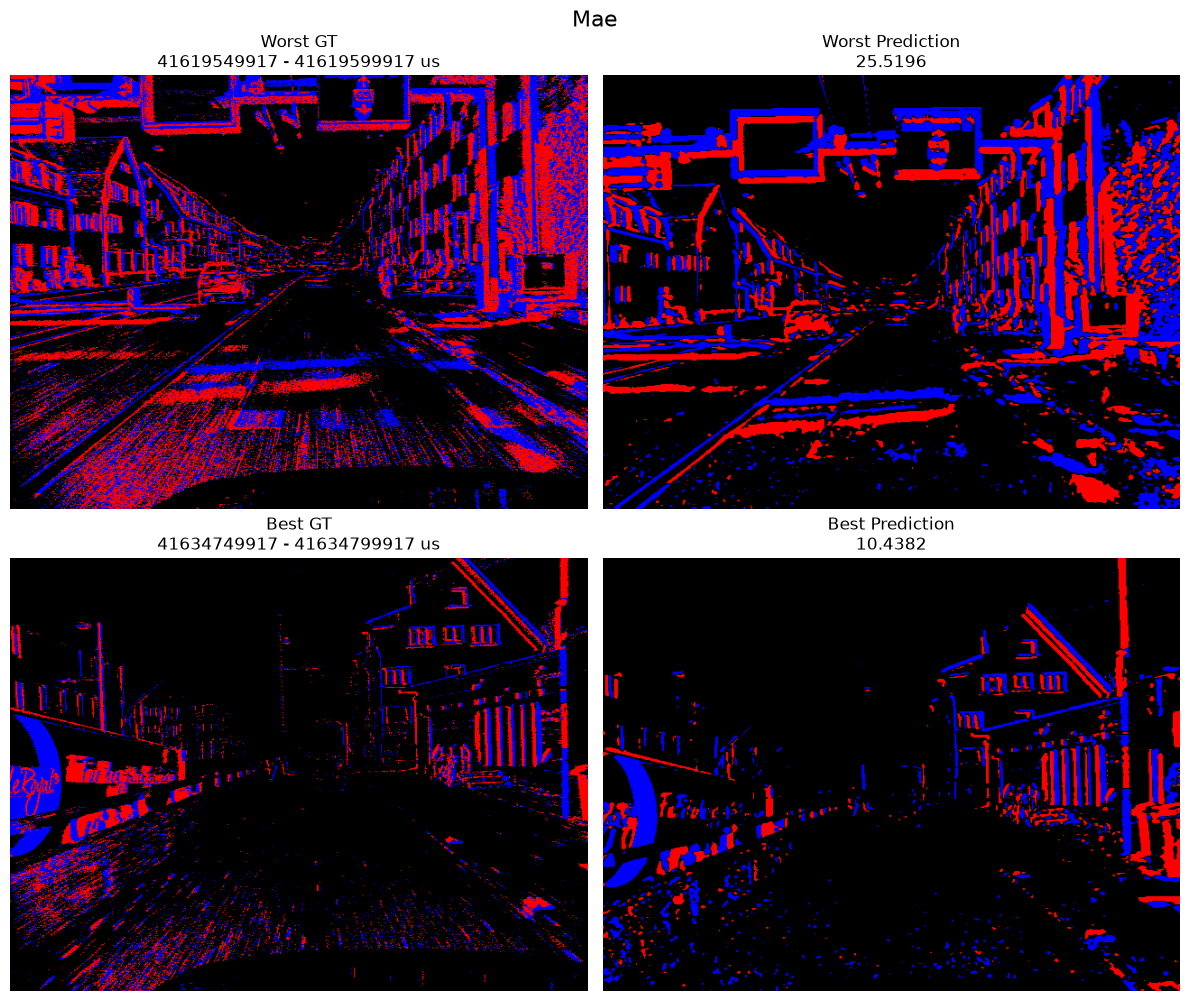

In [18]:
plot_best_worst(results, gt_slicer, pred_slicer, "mae")

In [19]:
import pandas as pd

image_metrics = {
    "MSE": ("mse", True),
    "MAE": ("mae", True),
    "PSNR": ("psnr", False),
    "SSIM": ("ssim", False),
    "LPIPS": ("lpips", True),
}

rows = []

for name, (key, lower_is_better) in image_metrics.items():
    values = [r["images"][key] for r in results]

    rows.append({
        "Metric": name,
        "Mean": sum(values) / len(values),
        "Best": min(values) if lower_is_better else max(values),
        "Worst": max(values) if lower_is_better else min(values),
    })

image_table = pd.DataFrame(rows)
print(image_table.to_markdown(index=False, floatfmt=".4f"))

| Metric   |      Mean |     Best |     Worst |
|:---------|----------:|---------:|----------:|
| MSE      | 1246.3672 | 642.4761 | 1623.4905 |
| MAE      |   20.1938 |  10.4382 |   25.5196 |
| PSNR     |   17.2253 |  20.0522 |   16.0263 |
| SSIM     |    0.2644 |   0.4685 |    0.1443 |
| LPIPS    |    0.6511 |   0.5495 |    1.0414 |


In [20]:
event_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
]

rows = []

for metric in event_metrics:
    row = {"Mean Metric": metric.upper()}

    for event_type in ["all", "on", "off"]:
        values = [r["events"][event_type][metric] for r in results]
        row[event_type.upper()] = sum(values) / len(values)

    rows.append(row)

event_table = pd.DataFrame(rows)
print(event_table.to_markdown(index=False, floatfmt=".4f"))

| Mean Metric   |    ALL |     ON |    OFF |
|:--------------|-------:|-------:|-------:|
| ACCURACY      | 0.7932 | 0.7094 | 0.7185 |
| PRECISION     | 0.9356 | 0.8984 | 0.9304 |
| RECALL        | 0.8093 | 0.7237 | 0.7205 |
| F1            | 0.8675 | 0.8006 | 0.8110 |


In [21]:
coverage_metrics = [
    "mean_cov",
    "median_cov",
    "std_cov",
    "p25_cov",
    "p75_cov",
    "cov_gt_05",
    "cov_gt_07",
    "cov_gt_10",
]

def coverage_table(results, coverage_type):

    rows = []

    for metric in coverage_metrics:

        row = {"Metric": metric}

        for event_type in ["all", "on", "off"]:

            values = [
                r["events"][event_type][coverage_type][metric]
                for r in results
            ]

            row[event_type.upper()] = sum(values) / len(values)

        rows.append(row)

    return pd.DataFrame(rows)

absolute_table = coverage_table(results, "absolute_coverage")
normalized_table = coverage_table(results, "normalized_coverage")
print(absolute_table.to_markdown(index=False, floatfmt=".4f"))

print()

print(normalized_table.to_markdown(index=False, floatfmt=".4f"))

| Metric     |     ALL |      ON |     OFF |
|:-----------|--------:|--------:|--------:|
| mean_cov   |  3.9254 |  3.2783 |  2.7765 |
| median_cov |  0.1717 |  0.1101 |  0.1491 |
| std_cov    | 21.8852 | 16.9766 | 13.8802 |
| p25_cov    |  0.0258 |  0.0056 |  0.0090 |
| p75_cov    |  0.7505 |  0.5997 |  0.7131 |
| cov_gt_05  |  0.2990 |  0.2644 |  0.2943 |
| cov_gt_07  |  0.2506 |  0.2242 |  0.2441 |
| cov_gt_10  |  0.2100 |  0.1903 |  0.2023 |

| Metric     |      ALL |       ON |     OFF |
|:-----------|---------:|---------:|--------:|
| mean_cov   |  20.5825 |  19.9917 | 12.0820 |
| median_cov |   0.9059 |   0.6682 |  0.6415 |
| std_cov    | 115.4358 | 104.2285 | 60.9271 |
| p25_cov    |   0.1365 |   0.0329 |  0.0353 |
| p75_cov    |   3.9469 |   3.6196 |  3.0958 |
| cov_gt_05  |   0.6024 |   0.5352 |  0.5329 |
| cov_gt_07  |   0.5458 |   0.4878 |  0.4849 |
| cov_gt_10  |   0.4761 |   0.4318 |  0.4256 |
